# Life-Cycle Labor Supply of Couples

Solves and simulates a $T$-period labor supply model with two-earner couples. <br>
**Motivated** by the study “Are Marriage-Related Taxes and Social Security Benefits Holding Back Female Labor Supply?” by Borella et al. (forthcoming). <br>
**Goal** is to replicate effects of individual vs. joint taxation.

For simplicity, couples cannot divorce nor save.

The **Bellman equation** and the recursive formulation of our simple model is 
$$
\begin{align*}
V_{t}(K_{1,t},K_{2,t}) & =\max_{h_{1,t},h_{2,t}}U(c_{t},h_{1,t},h_{2,t})+\beta V_{t+1}(K_{1,t+1},K_{2,t+1})\\
c_{t} & =\sum_{j=1}^{2}w_{j,t}h_{j,t}-T(w_{1,t}h_{1,t},w_{2,t}h_{2,t})\\
\log w_{j,t} & =\alpha_{j,0}+\alpha_{j,1}K_{j,t},\;j\in\{1,2\}\\
K_{j,t+1} & =(1-\delta)K_{j,t}+h_{j,t},\;j\in\{1,2\}
\end{align*}
$$

**Preferences** are sum of individuals
$$
U(c_{t},h_{1,t},h_{2,t})=2\frac{(c_{t}/2)^{1+\eta}}{1+\eta}-\rho_{1}\frac{h_{1,t}^{1+\gamma}}{1+\gamma}-\rho_{2}\frac{h_{2,t}^{1+\gamma}}{1+\gamma}
$$

**Taxes** are on the household level
$$
T(Y_{1},Y_{2})=(1-\lambda(Y_{1}+Y_{2})^{-\tau})\cdot(Y_{1}+Y_{2})
$$

**Terminal period:** There are no bequests such that
$$
V_{T}(K_{1,T},K_{2,T})  =\max_{h_{1,T},h_{2,T}}U(c_{T},h_{1,T},h_{2,T})
$$

## Setup

In [34]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numba as nb

import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Dynamic Dual-Earner Model

In [35]:
# load local model file and initialize model class
from DynHouseholdLaborModel import DynHouseholdLaborModelClass
model = DynHouseholdLaborModelClass()

par = model.par
sol = model.sol
sim = model.sim

## Solve the model

In [36]:
model.solve()

# Question 1

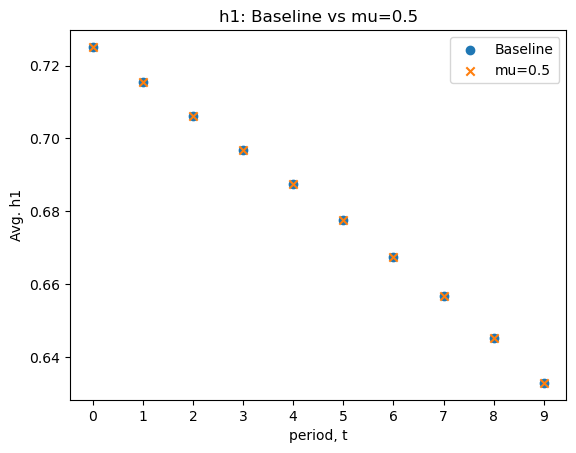

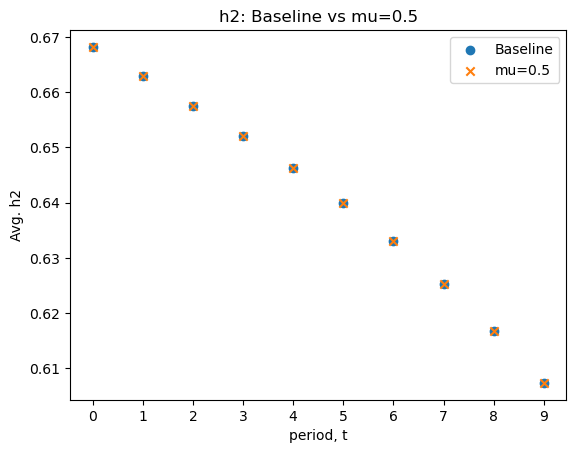

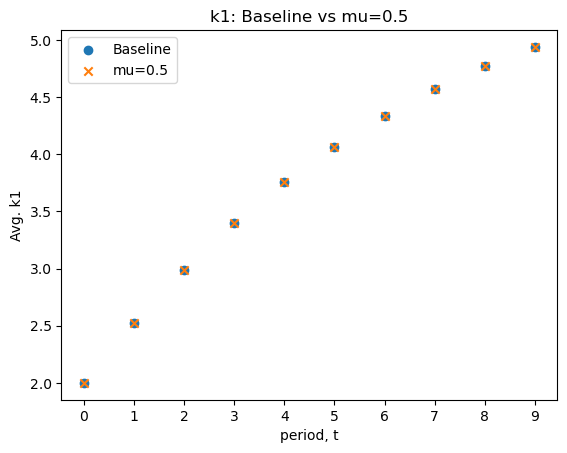

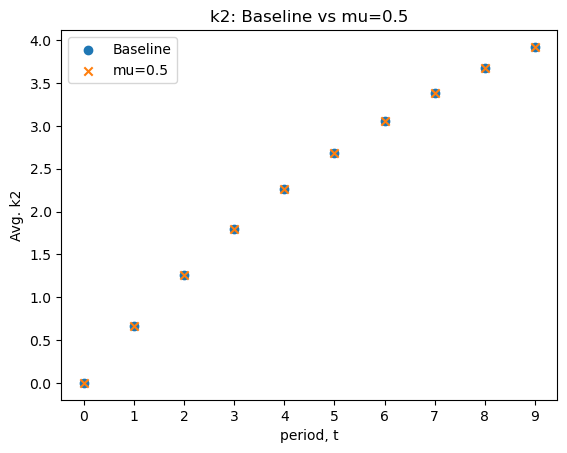

In [37]:
# Create baseline model (original)
model_baseline = DynHouseholdLaborModelClass()
model_baseline.solve()
model_baseline.sim.k1_init = 2.0 * np.ones(par.simN)
model_baseline.simulate()

# Create new model with mu = 0.5
model_mu = DynHouseholdLaborModelClass(par={'mu': 0.5})
model_mu.solve()
model_mu.sim.k1_init = 2.0 * np.ones(model_mu.par.simN)
model_mu.simulate()

# Plot both side by side to verify they are identical
for var in ('h1', 'h2', 'k1', 'k2'):
    fig, ax = plt.subplots()
    ax.scatter(range(par.simT), np.mean(getattr(model_baseline.sim, var), axis=0), 
               label='Baseline', marker='o')
    ax.scatter(range(par.simT), np.mean(getattr(model_mu.sim, var), axis=0), 
               label='mu=0.5', marker='x')
    ax.set(xlabel='period, t', ylabel=f'Avg. {var}', xticks=range(par.simT))
    ax.legend()
    plt.title(f'{var}: Baseline vs mu=0.5')

In [38]:
# Numerical check - max difference should be (close to) zero
for var in ('h1', 'h2'):
    diff = np.max(np.abs(getattr(model_baseline.sim, var) - getattr(model_mu.sim, var)))
    print(f'Max difference in {var}: {diff:.2e}')

Max difference in h1: 0.00e+00
Max difference in h2: 0.00e+00


# Question 3

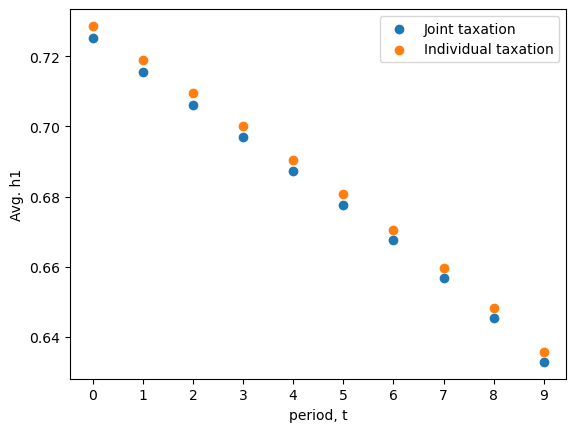

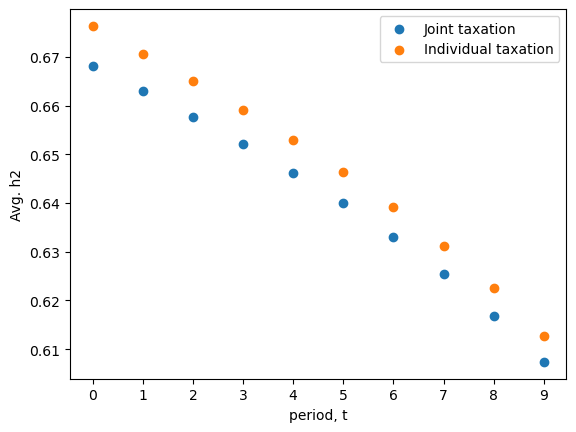

In [39]:
# Joint taxation (baseline with asymmetric human capital)
model_joint = DynHouseholdLaborModelClass()
model_joint.solve()
model_joint.sim.k1_init = 2.0 * np.ones(par.simN)
model_joint.sim.k2_init = 0.0 * np.ones(par.simN)
model_joint.simulate()

# Individual taxation
model_indiv = DynHouseholdLaborModelClass(par={'joint_tax': False})
model_indiv.solve()
model_indiv.sim.k1_init = 2.0 * np.ones(model_indiv.par.simN)
model_indiv.sim.k2_init = 0.0 * np.ones(model_indiv.par.simN)
model_indiv.simulate()

# Plot labor supply responses
for var in ('h1', 'h2'):
    fig, ax = plt.subplots()
    ax.scatter(range(par.simT), np.mean(getattr(model_joint.sim, var), axis=0),
               label='Joint taxation')
    ax.scatter(range(par.simT), np.mean(getattr(model_indiv.sim, var), axis=0),
               label='Individual taxation')
    ax.set(xlabel='period, t', ylabel=f'Avg. {var}', xticks=range(par.simT))
    ax.legend()

# Question 4

In [40]:
# Compute tax revenue for each individual in each period
def compute_tax_revenue(model):
    par = model.par
    sim = model.sim
    tax = np.zeros((par.simN, par.simT))
    for i in range(par.simN):
        for t in range(par.simT):
            if par.joint_tax:
                tax[i,t] = model.tax_func(sim.income1[i,t] + sim.income2[i,t])
            else:
                tax[i,t] = model.tax_func(sim.income1[i,t]) + model.tax_func(sim.income2[i,t])
    return np.mean(tax)  # average per household per period

budget_joint = compute_tax_revenue(model_joint)
budget_indiv = compute_tax_revenue(model_indiv)

delta_budget = budget_indiv - budget_joint
print(f'Budget under joint taxation:      {budget_joint:.4f}')
print(f'Budget under individual taxation: {budget_indiv:.4f}')
print(f'Change in government budget:      {delta_budget:.4f}')

Budget under joint taxation:      361.0473
Budget under individual taxation: 534.2984
Change in government budget:      173.2511


# Question 5

In [41]:
from scipy.optimize import brentq

def budget_diff(lambda_indiv):
    # Create model with new lambda
    model_try = DynHouseholdLaborModelClass(par={'joint_tax': False, 
                                                  'tax_scale_indiv': lambda_indiv})
    model_try.solve()
    model_try.sim.k1_init = 2.0 * np.ones(model_try.par.simN)
    model_try.sim.k2_init = 0.0 * np.ones(model_try.par.simN)
    model_try.simulate()
    
    budget_i = compute_tax_revenue(model_try)
    return budget_i - budget_joint

# Find lambda_star using Brent's method
lambda_star = brentq(budget_diff, 1.0, 3.0)
print(f'lambda_indiv_star = {lambda_star:.6f}')

lambda_indiv_star = 1.766990


# Question 6

In [45]:
from consav.linear_interp import interp_2d

# Model with lambda_star
model_indiv_star = DynHouseholdLaborModelClass(par={'joint_tax': False,
                                                     'tax_scale_indiv': lambda_star})
model_indiv_star.solve()

# Case 1: K1_0 = 2, K2_0 = 0
V0_joint_asym = interp_2d(model_joint.par.k_grid, model_joint.par.k_grid,
                           model_joint.sol.V[0], 2.0, 0.0)
V0_indiv_asym = interp_2d(model_indiv_star.par.k_grid, model_indiv_star.par.k_grid,
                           model_indiv_star.sol.V[0], 2.0, 0.0)
print(f'Case 1: K1=2, K2=0')
print(f'V0 joint taxation:      {V0_joint_asym:.10f}')
print(f'V0 individual taxation: {V0_indiv_asym:.10f}')
print(f'Difference:             {V0_indiv_asym - V0_joint_asym:.10f}')

# Case 2: K1_0 = 8, K2_0 = 8 - reuse model_joint!
V0_joint_sym = interp_2d(model_joint.par.k_grid, model_joint.par.k_grid,
                          model_joint.sol.V[0], 8.0, 8.0)
V0_indiv_sym = interp_2d(model_indiv_star.par.k_grid, model_indiv_star.par.k_grid,
                          model_indiv_star.sol.V[0], 8.0, 8.0)
print(f'\nCase 2: K1=8, K2=8')
print(f'V0 joint taxation:      {V0_joint_sym:.10f}')
print(f'V0 individual taxation: {V0_indiv_sym:.10f}')
print(f'Difference:             {V0_indiv_sym - V0_joint_sym:.10f}')

Case 1: K1=2, K2=0
V0 joint taxation:      -0.2267191082
V0 individual taxation: -0.2266890803
Difference:             0.0000300279

Case 2: K1=8, K2=8
V0 joint taxation:      -0.1890851465
V0 individual taxation: -0.1883394834
Difference:             0.0007456630
